<a href="https://colab.research.google.com/github/Md-Salman-Rahman339/AI-ML-Final-Exam-Medical-cost-insurance-predictor/blob/main/Copy_of_ML_Final_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading:

In [57]:

import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#sklearn preprocessing

from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


#Regression model

from sklearn.linear_model import LinearRegression,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



from sklearn.ensemble import VotingRegressor, StackingRegressor


#metrices

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

In [58]:
df = pd.read_csv("/content/insurance.csv")

In [59]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [60]:
print(df.shape)

(1338, 7)


# Data Preprocessing:

In [61]:
print("Missing Values:\n")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing Values:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing: 0


# Encode categorical Variables

In [62]:
cat_features=df.select_dtypes(include='object').columns
print("categorical columns:",list(cat_features))


le=LabelEncoder()
for col in cat_features:
  df[col]=le.fit_transform(df[col])
df.head()

categorical columns: ['sex', 'smoker', 'region']


,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [46]:
num_cols=X.select_dtypes(include=['int64','float64']).columns
cat_cols=X.select_dtypes(include=['object']).columns

print("\n Numerical Columns:",list(num_cols))
print("\n Categorical columns:",list(cat_cols))


 Numerical Columns: ['age', 'bmi', 'children']

 Categorical columns: ['sex', 'smoker', 'region']


# Outlier Detection:

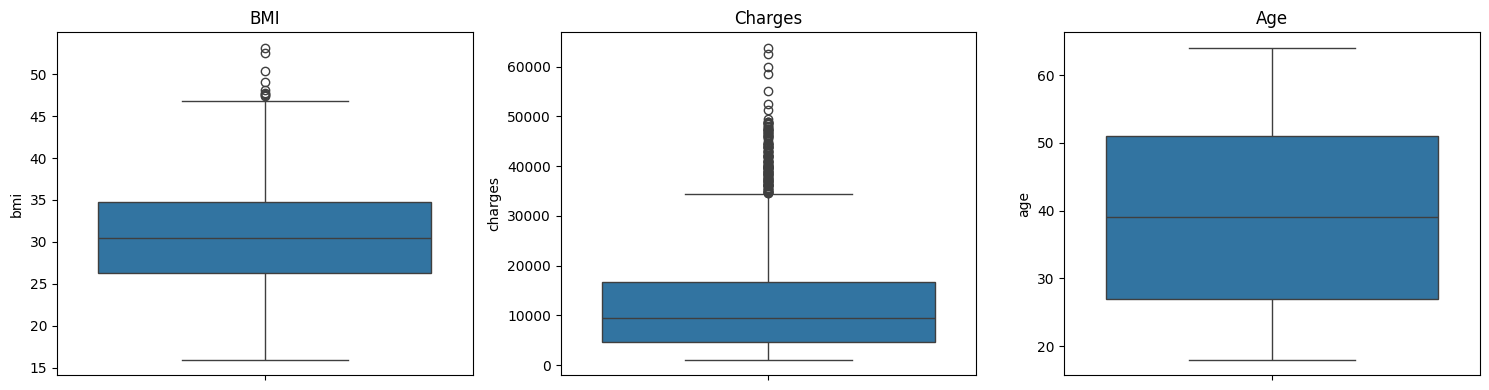

In [63]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
sns.boxplot(data=df,y='bmi',ax=axes[0])
axes[0].set_title('BMI')

sns.boxplot(data=df,y='charges',ax=axes[1])
axes[1].set_title('Charges')

sns.boxplot(data=df,y='age',ax=axes[2])
axes[2].set_title('Age')

plt.tight_layout()
plt.show()



# Remove Outlier:

In [64]:
def remove_outliers(df,col):
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  df[col]=df[col].clip(lower=lower,upper=upper)
  return df

for col in ['bmi','charges']:
  df=remove_outliers(df,col)

print("Outlier handle succssfully")

Outlier handle succssfully


# Feature engineering:

In [65]:
df['bmi_category']=pd.cut(
    df['bmi'],
    bins=[0,18.5,24.9,29.9,100],
    labels=[0,1,2,3]
)

df['age_group']=pd.cut(
    df['age'],
    bins=[0,18,35,50,100],
    labels=[0,1,2,3]
)

df['family_size']=df['children']+1

df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,family_size
0,19,0,27.900,0,1,3,16884.92400,2,1,1
1,18,1,33.770,1,0,2,1725.55230,3,0,2
2,28,1,33.000,3,0,2,4449.46200,3,1,4
3,33,1,22.705,0,0,1,21984.47061,1,1,1
4,32,1,28.880,0,0,1,3866.85520,2,1,1


# Correlation Heatmap:

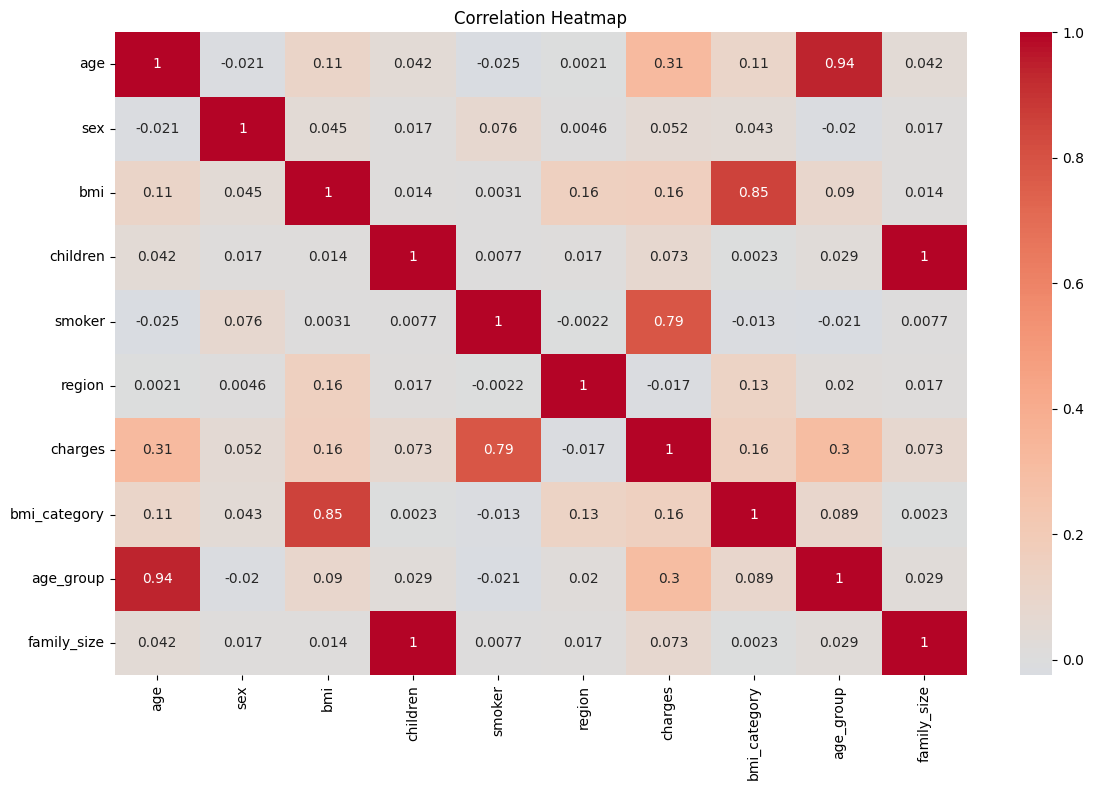

In [66]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm',center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# split data into features and target

In [15]:
X=df.drop(columns=['charges'])
y=df["charges"]

print(f"Features shape:{X.shape}")

Features shape:(1338, 6)


# Train-Test-Split

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Training set:{X_train.shape}")
print(f"test set:{X_test.shape}")

Training set:(1070, 6)
test set:(268, 6)


# Pipeline Creation:

In [24]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestRegressor(n_estimators=100, random_state=42))
])

print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('classifier', RandomForestRegressor(random_state=42))])


Random Forest Regressor is selected cause it can handle both numerical and categorical features effectively,it can capture non-linear relationships and reduce overfitting and it can perform strongly on tabular datasets like medical cost prediction

# Model Training

In [25]:
pipeline.fit(X_train,y_train)

train_pred=pipeline.predict(X_train)
r2=r2_score(y_train,train_pred)
rmse=np.sqrt(mean_squared_error(y_train,train_pred))
mae=mean_absolute_error(y_train,train_pred)

print(f"r2_score:{r2}")
print(f"rmse:{rmse}")
print(f"mae:{mae}")

r2_score:0.9749626952357883
rmse:1900.9799788695125
mae:1035.8596196694637


# Cross Validation:

In [30]:
from sklearn.model_selection import cross_val_score
cv_score=cross_val_score(pipeline,X_train,y_train,cv=5,scoring='r2')
print(cv_score)
print(f"Mean:{cv_score.mean():.4f}")
print(f"std is:{cv_score.std():.4f}")

[0.81917294 0.9007374  0.79823447 0.78634203 0.83589682]
Mean:0.8281
std is:0.0401


# Hyperparameter Tuning:

In [36]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth':[None,10,20],
    'classifier__min_samples_split':[2,5]

}

grid_search=GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train,y_train)

print(f"Best parameters:{grid_search.best_params_}\n")
print(f"Best score:{grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best score:0.8338



In [37]:
results_df=pd.DataFrame(grid_search.cv_results_)
top_results=results_df[['params','std_test_score','mean_test_score','rank_test_score']].sort_values(by='rank_test_score').head(10)
top_results

,params,std_test_score,mean_test_score,rank_test_score
7,"{'classifier__max_depth': 10, 'classifier__min...",0.042295,0.833817,1
6,"{'classifier__max_depth': 10, 'classifier__min...",0.042093,0.833708,2
11,"{'classifier__max_depth': 20, 'classifier__min...",0.042072,0.833077,3
3,"{'classifier__max_depth': None, 'classifier__m...",0.042075,0.833075,4
10,"{'classifier__max_depth': 20, 'classifier__min...",0.041708,0.833000,5
2,"{'classifier__max_depth': None, 'classifier__m...",0.041714,0.832995,6
5,"{'classifier__max_depth': 10, 'classifier__min...",0.040752,0.830734,7
4,"{'classifier__max_depth': 10, 'classifier__min...",0.040256,0.830630,8
1,"{'classifier__max_depth': None, 'classifier__m...",0.040631,0.828494,9
9,"{'classifier__max_depth': 20, 'classifier__min...",0.040592,0.828433,10


# Best Model:

In [38]:
best_model=grid_search.best_estimator_

print("Best model:\n")
print(best_model)

print(f"Best parameters:{grid_search.best_params_}")
print(f"Best score:{grid_search.best_score_:.4f}")

Best model:

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['sex', 'smoker', 'region'], dtype='object'))])),
                ('classifier',
                 RandomForestRegressor(max_depth=10, min_samples_split=5,
                                       n_estimators=200, random_state=42))])
Best parameters:{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best score:0.8338


# Model Performance evaluation:

In [44]:
y_pred=best_model.predict(X_test)

r2_s=r2_score(y_test,y_pred)
print(f"Test R2 Score: {r2_s:.4f}")

rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f"Test RMSE: {rmse:.4f}")

mae=mean_absolute_error(y_test,y_pred)
print(f"Test MAE: {mae:.4f}")

Test R2 Score: 0.8687
Test RMSE: 4515.3787
Test MAE: 2519.6621


# Save the model

In [45]:
with open('model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

with open('features_names.pkl',"wb") as f:
  pickle.dump(X.columns,f)


print("Model saved as model.pkl")

print("features saved as feature_names.pkl")

Model saved as model.pkl
features saved as feature_names.pkl
